In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

### Oppgave 1.1

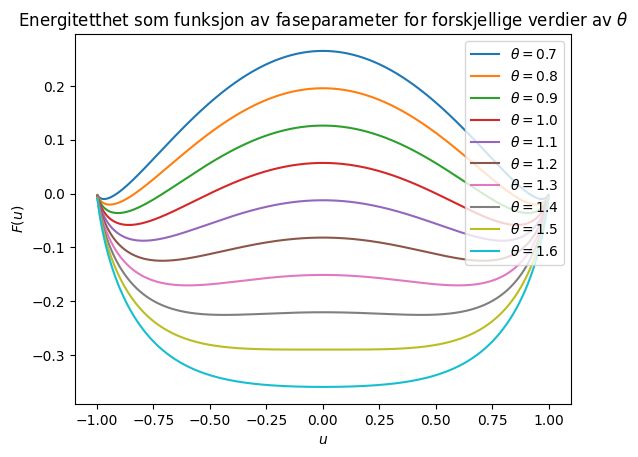

In [2]:
def F(u, theta, theta_C):
    return ((theta_C / 2) * (1 - u**2)) + ((theta / 2) * ((1 - u) * np.log((1 - u) / 2) + (1 + u) * np.log((1 + u) / 2)))

theta = np.array([0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6])
theta_C = 1.5
u = np.linspace(-1, 1, 1001)

plt.figure()
for th in theta:
    plt.plot(u, F(u, th, theta_C), label=r'$\theta = {}$'.format(th))
plt.title(fr'Energitetthet som funksjon av faseparameter for forskjellige verdier av $\theta$')
plt.xlabel(r'$u$')
plt.ylabel(r'$F(u)$')
plt.legend()
plt.show()



### Oppgave 1.2 – Symmetri under fortegnsbytte

Vi skal vise at Cahn–Hilliard-ligningen er invariant under transformasjonen  
$ u(x,t) \mapsto -u(x,t) $.  
Det vil si at hvis $ u(x,t) $ er en løsning, så er også $ -u(x,t) $ en løsning.

#### Cahn–Hilliard-ligningen

Vi starter med ligningen
$
\frac{\partial u}{\partial t} = \Delta \mu, \quad \text{der} \quad \mu = -\varepsilon^2 \Delta u + f(u),
$
og $ f(u) = (u^2 - 1)u $.

#### Anta at $ u(x,t) $ er en løsning, og definer $ v(x,t) := -u(x,t) $

Vi viser at $ v $ også tilfredsstiller ligningen:

- Tidsderivert:
$
\frac{\partial v}{\partial t} = -\frac{\partial u}{\partial t}
$

- Laplace:
$
\Delta v = -\Delta u
$

- Ikke-lineær funksjon:
$
f(v) = f(-u) = ((-u)^2 - 1)(-u) = (u^2 - 1)(-u) = -f(u)
$

- Kjemisk potensial for $ v $:
$
\mu_v = -\varepsilon^2 \Delta v + f(v)
= -\varepsilon^2 (-\Delta u) + (-f(u)) = \varepsilon^2 \Delta u - f(u)
= -\mu
$

- Tidsutvikling:
$
\frac{\partial v}{\partial t} = -\frac{\partial u}{\partial t} = -\Delta \mu = \Delta(-\mu) = \Delta \mu_v
$

#### Konklusjon

Vi har vist at hvis $ u(x,t) $ er en løsning, så er også $ -u(x,t) $ en løsning.  
Cahn–Hilliard-ligningen er altså **invariant under transformasjonen** $ u \mapsto -u $:
$
\boxed{u(x,t) \text{ er løsning } \Rightarrow -u(x,t) \text{ er også løsning}}
$

Dette følger fordi:
- Laplace-operatoren er lineær
- $ f(u) = (u^2 - 1)u $ er en odde funksjon: $ f(-u) = -f(u) $


### Oppgave 1.3 – Masskonservering i Cahn–Hilliard-ligningen

Vi skal vise at løsninger $u(x,t)$ av Cahn–Hilliard-ligningen som er periodiske på rektangulært domene 
$\Omega = [0, L_x] \times [0, L_y]$ er massekonservative, det vil si at:

$$
\frac{d}{dt} \int_\Omega u(x,t) \, dx = 0.
$$

Dette betyr at den totale massen (eller middelverdien av $u$) er bevart over tid.

#### Cahn–Hilliard-ligningen

Ligningen er gitt ved:

$$
\frac{\partial u}{\partial t} = \Delta \mu,
\quad \text{der} \quad \mu = -\varepsilon^2 \Delta u + f(u).
$$

#### Bevis

Vi integrerer begge sider av ligningen over $\Omega$:

$$
\frac{d}{dt} \int_\Omega u(x,t) \, dx
= \int_\Omega \frac{\partial u}{\partial t} \, dx
= \int_\Omega \Delta \mu \, dx.
$$

Vi bruker divergensteoremet:

$$
\int_\Omega \Delta \mu \, dx = \int_{\partial \Omega} \nabla \mu \cdot \mathbf{n} \, ds,
$$

der $\mathbf{n}$ er normalvektoren på randen $\partial \Omega$.

Siden $u$ (og dermed også $\mu$) er periodisk på domenet, vil funksjonen og dens gradient være like på motstående rander. Dette gjør at **randeintegralet kanselleres**, altså:

$$
\int_{\partial \Omega} \nabla \mu \cdot \mathbf{n} \, ds = 0.
$$

Dermed får vi:

$$
\frac{d}{dt} \int_\Omega u(x,t) \, dx = 0.
$$

#### Konklusjon

Vi har vist at den totale massen er konstant i tid:

$$
\boxed{
\int_\Omega u(x,t) \, dx = \text{konstant}
}
$$

Dette betyr at Cahn–Hilliard-ligningen er **masskonserverende** på et periodisk domene.


### Oppgave 2

In [3]:
def biharmonic_solver(X, Y, F, c, mean=0.0):
    """
    Solve the biharmonic equation in 2D using the spectral method.

    Parameters:
        X (ndarray): 2D array of x-coordinates.
        Y (ndarray): 2D array of y-coordinates.
        F (ndarray): 2D array representing the right-hand side of the biharmonic equation.
        c (float): Constant coefficient in the biharmonic equation.
        mean (float, optional): Desired mean value of the solution in case c = 0. Default is 0.0.

    Returns:
        U (ndarray): 2D array representing the solution to the biharmonic equation.
    """

    Nx = X.shape[0]
    Ny = Y.shape[1]

    # Compute the Fourier coefficients of the right-hand side
    F_hat = np.fft.fft2(F)

    # Compute the wavenumbers
    kx = np.fft.fftfreq(Nx, d=1/Nx)
    ky = np.fft.fftfreq(Ny, d=1/Ny)

    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    K2 = KX**2 + KY**2
    K4 = K2**2

    # Compute the Fourier coefficients of the solution
    U_hat = F_hat / (K4 + c)

    # Set the mean value of the solution
    U_hat[0, 0] = mean

    # Compute the solution
    U = np.real(np.fft.ifft2(U_hat))

    return U

In [4]:
Nx = np.array([4, 8, 15, 16, 20, 32])
Ny = 2 * Nx
c = 1.0

# Får rare/feil plot for domenegrenser som ikke er 1
domain_xmax = 1     # Skal være 2 * np.pi
domain_ymax = 1     # Skal være 4 * np.pi


Plotter i første omgang for alle N-verdiene for å tolke, men skal kun plotte for et par-tre N-verdier. 

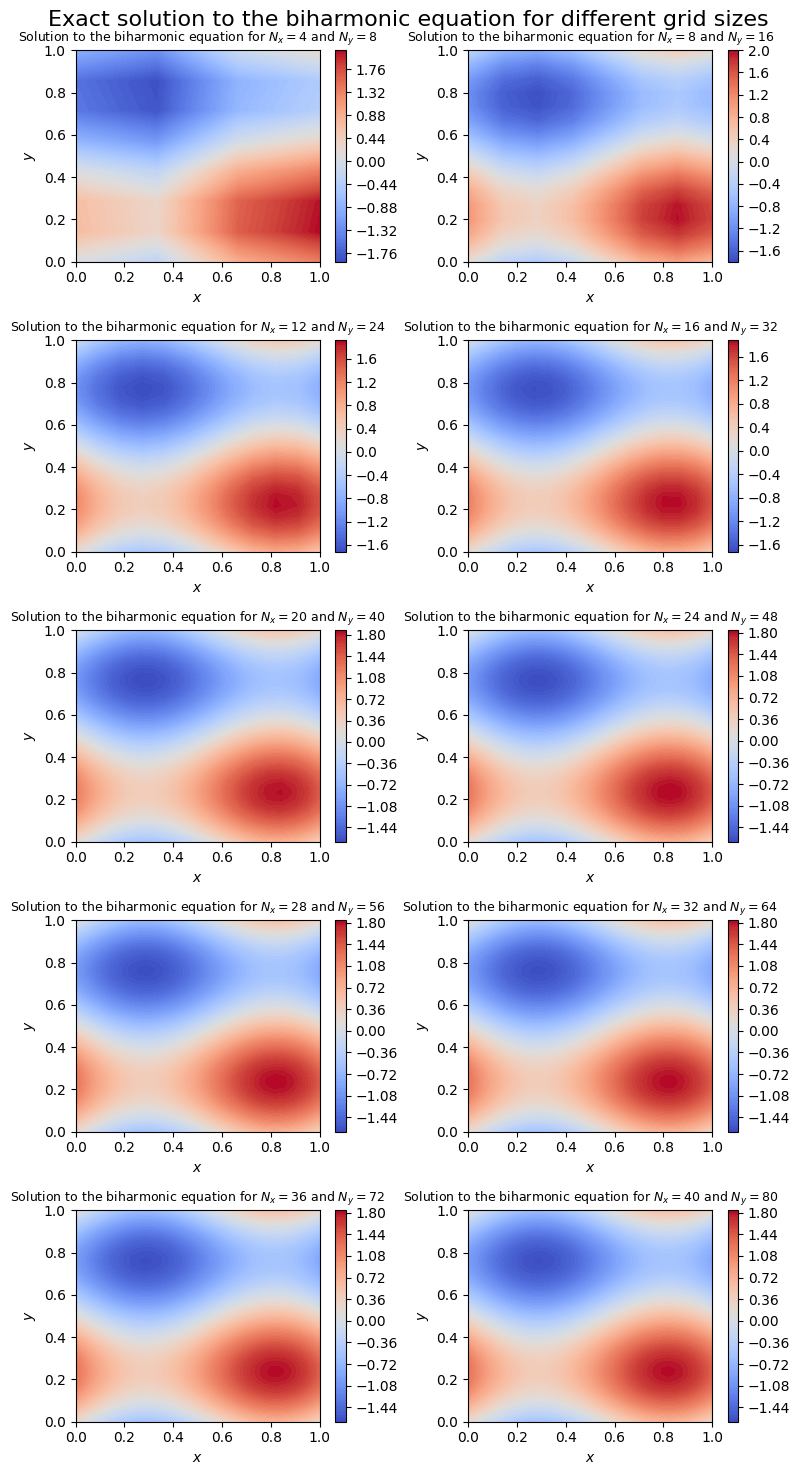

In [5]:
# Plot the solution
k = np.arange(10)  # Array of integers from 0 to 9
Nx = 4 + 4 * k
Ny = 2 * Nx
c = 0.0

plt.figure(figsize=(8, 15))
plt.suptitle("Exact solution to the biharmonic equation for different grid sizes", fontsize=16)
for i, (nx, ny) in enumerate(zip(Nx, Ny)):
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)

    F = np.exp(np.sin(X)**2 + np.cos(2 * Y))
    U = biharmonic_solver(X, Y, F, c)

    # Define the exact solution
    x, y = sp.symbols('x y')
    F_sym = sp.exp(sp.sin(x)) * sp.exp(sp.cos(2 * y))
    F_func = sp.lambdify((x, y), F_sym, modules='numpy')

    # Compute the exact solution
    U_exact = F_func(X, Y)

    plt.subplot(5, 2, i + 1)
    plt.contourf(X, Y, U, 100, cmap='coolwarm')
    plt.colorbar()
    plt.title(fr'Solution to the biharmonic equation for $N_x = {nx}$ and $N_y = {ny}$', fontsize=9)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
plt.tight_layout()
plt.show()

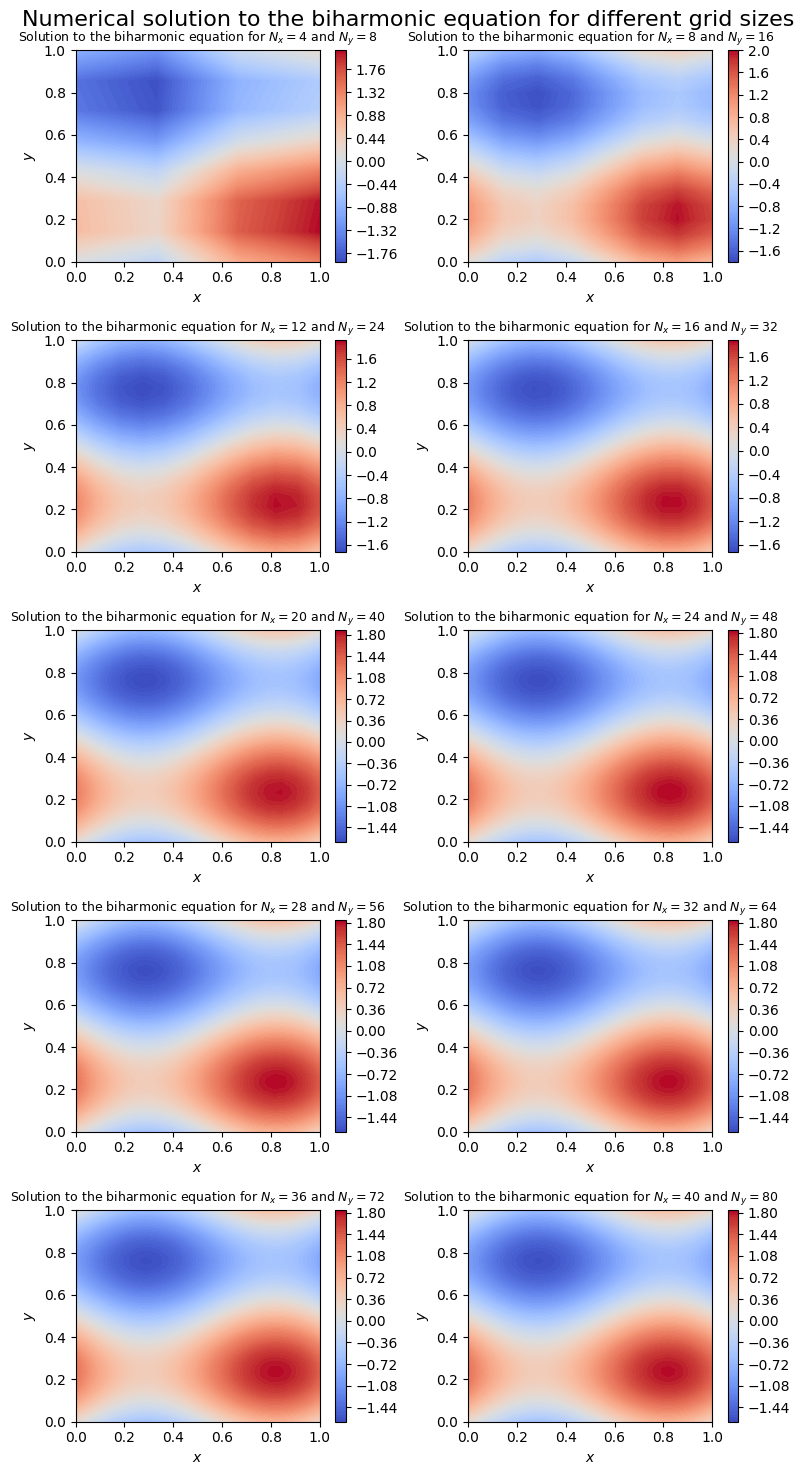

In [6]:
# Plot the solution
k = np.arange(10)  # Array of integers from 0 to 9
Nx = 4 + 4 * k
Ny = 2 * Nx
c = 0.0

plt.figure(figsize=(8, 15))
plt.suptitle("Numerical solution to the biharmonic equation for different grid sizes", fontsize=16)
for i, (nx, ny) in enumerate(zip(Nx, Ny)):
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    X, Y = np.meshgrid(x, y)

    F = np.exp(np.sin(X)**2 + np.cos(2 * Y))
    U = biharmonic_solver(X, Y, F, c)


    plt.subplot(5, 2, i + 1)
    plt.contourf(X, Y, U, 100, cmap='coolwarm')
    plt.colorbar()
    plt.title(fr'Solution to the biharmonic equation for $N_x = {nx}$ and $N_y = {ny}$', fontsize=9)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
plt.tight_layout()
plt.show()

### Tolkning

Tror plottene gir mening. Blir glattere og mer definert for høyere N (oppløsning). Lagt til bilde i mappen av funksjonene i mappen også for sammenligning, ikke til bruk i innlevering.

Første numeriske løsningen er litt feil.

ValueError: num must be an integer with 1 <= num <= 6, not 7

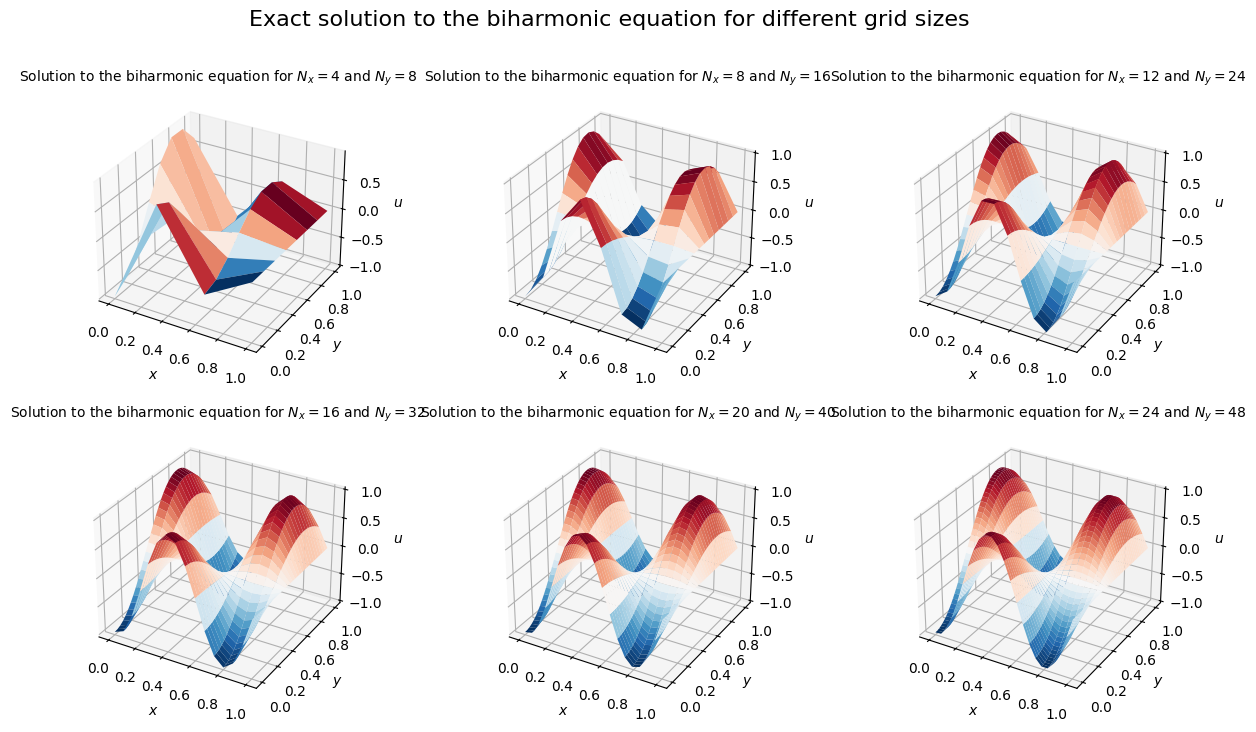

In [7]:
# Plot the solution
fig = plt.figure(figsize=(15, 8))
plt.suptitle("Exact solution to the biharmonic equation for different grid sizes", fontsize=16)
for i, (nx, ny) in enumerate(zip(Nx, Ny)):
    x = np.linspace(0, domain_xmax, nx)
    y = np.linspace(0, domain_ymax, ny)
    X, Y = np.meshgrid(x, y)

    # Define the exact solution
    x, y = sp.symbols('x y')
    F_sym = sp.sin(8 * (x - 1)) * sp.cos(4 * y)
    F_func = sp.lambdify((x, y), F_sym, modules='numpy')

    # Compute the exact solution
    U_exact = F_func(X, Y)

    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    surf = ax.plot_surface(X, Y, U_exact, cmap='RdBu_r', edgecolor='none')

    ax.set_title(fr'Solution to the biharmonic equation for $N_x = {nx}$ and $N_y = {ny}$', fontsize=10)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_zlabel(r'$u$')
plt.tight_layout()
plt.show()

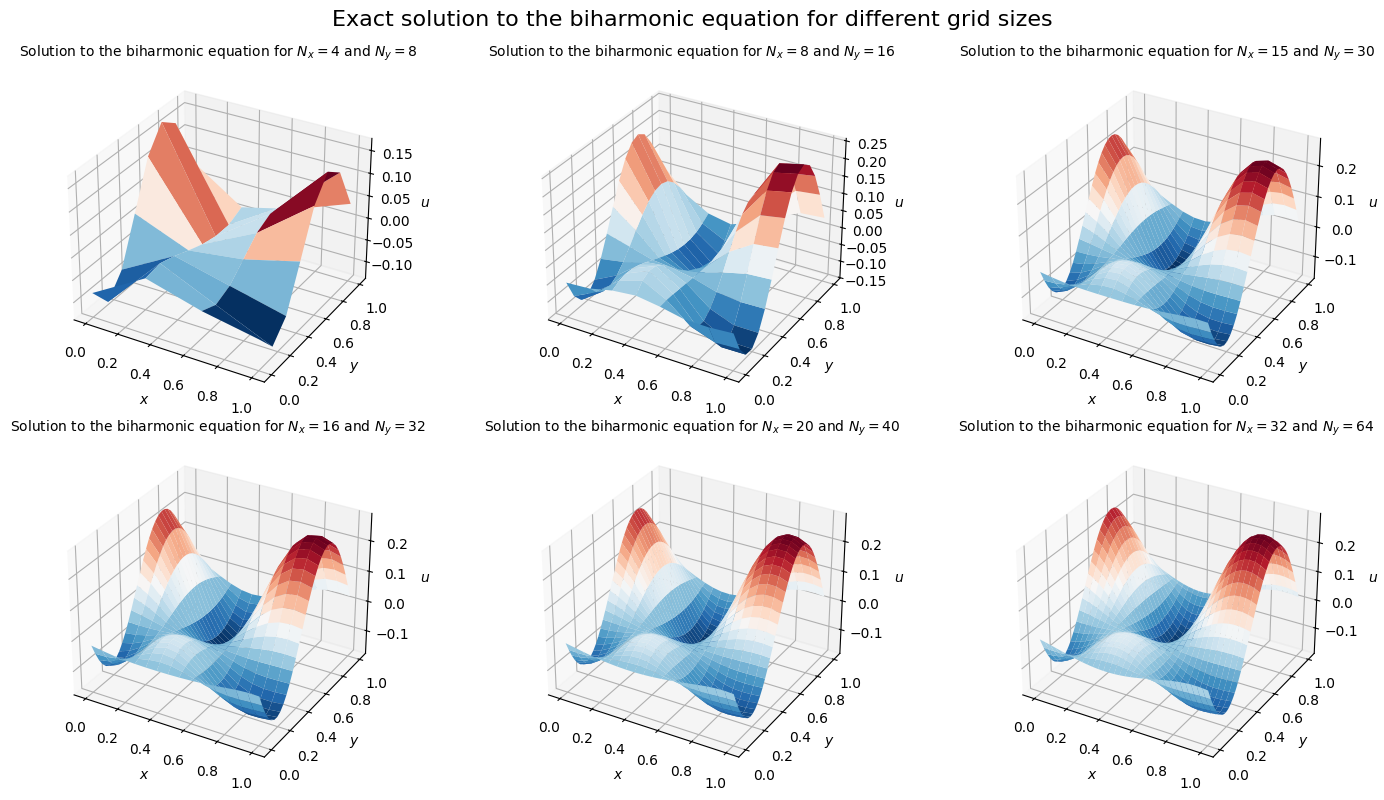

In [ ]:
# Plot the solution
fig = plt.figure(figsize=(15, 8))
plt.suptitle("Exact solution to the biharmonic equation for different grid sizes", fontsize=16)
for i, (nx, ny) in enumerate(zip(Nx, Ny)):
    x = np.linspace(0, domain_xmax, nx)
    y = np.linspace(0, domain_ymax, ny)
    X, Y = np.meshgrid(x, y)

    # Define the right-hand side of the biharmonic equation
    F = np.sin(8 * (X - 1)) * np.cos(4 * Y)
    U = biharmonic_solver(X, Y, F, c)

    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    surf = ax.plot_surface(X, Y, U, cmap='RdBu_r', edgecolor='none')

    ax.set_title(fr'Solution to the biharmonic equation for $N_x = {nx}$ and $N_y = {ny}$', fontsize=10)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_zlabel(r'$u$')
plt.tight_layout()
plt.show()

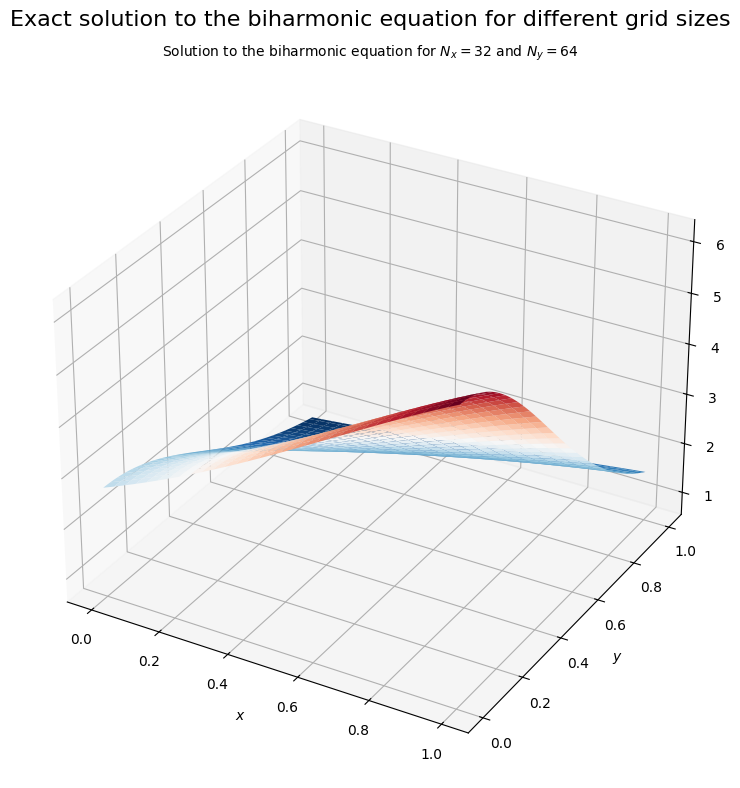

In [ ]:
# Plot the solution
k = np.arange(10)  # Array of integers from 0 to 9
Nx = 4 + 4 * k
Ny = 2 * Nx
c = 0.0

Nx = np.array([32])
Ny = 2 * Nx

# Plot the solution
fig = plt.figure(figsize=(15, 8))
plt.suptitle("Exact solution to the biharmonic equation for different grid sizes", fontsize=16)
for i, (nx, ny) in enumerate(zip(Nx, Ny)):
    x = np.linspace(0, domain_xmax, nx)
    y = np.linspace(0, domain_ymax, ny)
    X, Y = np.meshgrid(x, y)

    # Define the exact solution
    x, y = sp.symbols('x y')
    F_sym = sp.exp(sp.sin(x)) * sp.exp(sp.cos(2 * y))
    F_func = sp.lambdify((x, y), F_sym, modules='numpy')

    # Compute the exact solution
    U_exact = F_func(X, Y)

    ax = fig.add_subplot(1, 1, i + 1, projection='3d')
    surf = ax.plot_surface(X, Y, U_exact, cmap='RdBu_r', edgecolor='none')

    ax.set_title(fr'Solution to the biharmonic equation for $N_x = {nx}$ and $N_y = {ny}$', fontsize=10)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')
    ax.set_zlabel(r'$u$')
plt.tight_layout()
plt.show()